## TASK 4

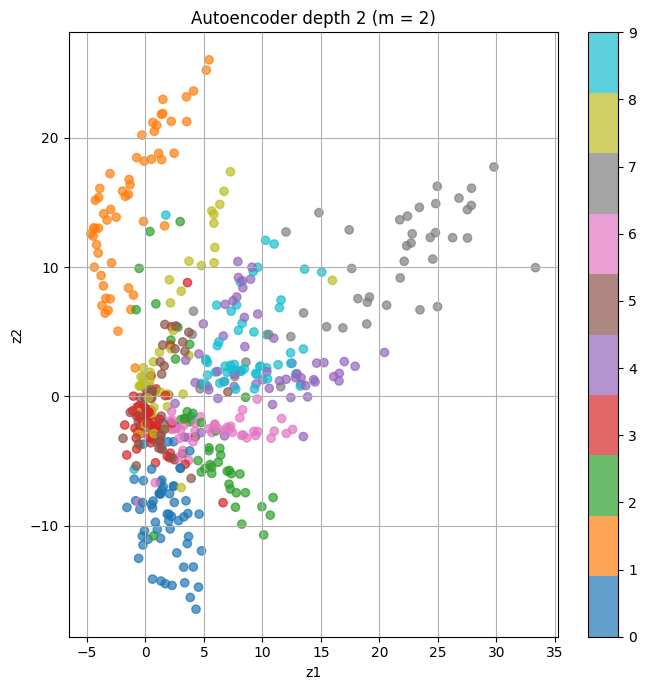

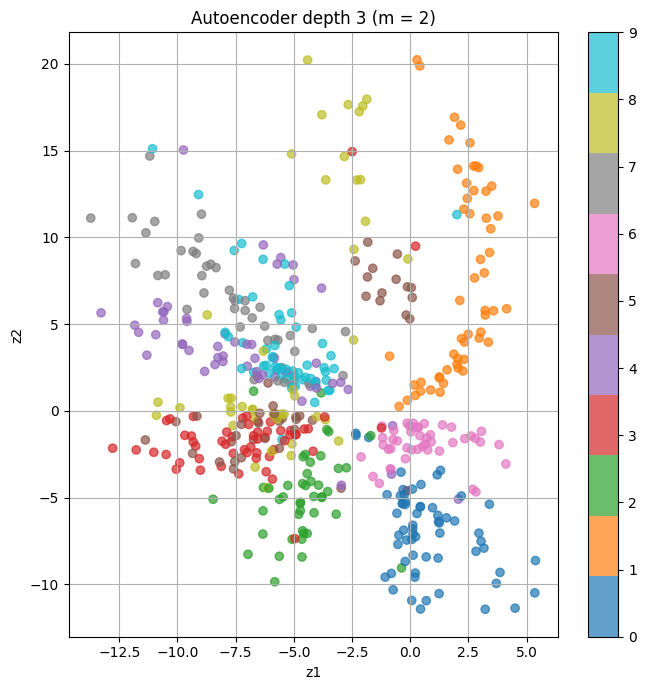

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# data normalization 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST("data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# subset for visualization
np.random.seed(42)
PLOT_SAMPLES = 500
test_dataset = datasets.MNIST("data", train=False, download=True, transform=transform)
plot_indices = np.random.choice(len(test_dataset), PLOT_SAMPLES, replace=False)
plot_subset = Subset(test_dataset, plot_indices)
plot_loader = DataLoader(plot_subset, batch_size=PLOT_SAMPLES, shuffle=False)


class Autoencoder(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.depth = depth
        input_dim = 28 * 28
        hidden_dim = 64
        bottleneck_dim = 2

        # encoder
        if depth == 2:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, bottleneck_dim)
            )
        elif depth == 3:
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, bottleneck_dim)
            )

        # decoder mirrors encoder 
        if depth == 2:
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim)
            )
        elif depth == 3:
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim)
            )

    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


def train_autoencoder(model, loader, optimizer, criterion, epochs):
    model.train()
    for epoch in range(epochs):
        for x, _ in loader:
            x = x.to(device)
            target = x.view(x.size(0), -1)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()


def plot_latent_space(model, loader, title, filename):
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.encode(x).cpu().numpy()
            labels = y.numpy()

            plt.figure(figsize=(7, 7))
            scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap="tab10", alpha=0.7)
            plt.xlabel("z1")
            plt.ylabel("z2")
            plt.title(title)
            plt.colorbar(scatter, ticks=range(10))
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(filename, dpi=300)
            plt.show()


# model 1 
model_depth2 = Autoencoder(depth=2).to(device)
optimizer2 = optim.Adam(model_depth2.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_autoencoder(model_depth2, train_loader, optimizer2, criterion, epochs=40)

# model 2
model_depth3 = Autoencoder(depth=3).to(device)
optimizer3 = optim.Adam(model_depth3.parameters(), lr=1e-3)

train_autoencoder(model_depth3, train_loader, optimizer3, criterion, epochs=40)

# latent space visualizations
plot_latent_space(
    model_depth2,
    plot_loader,
    "Autoencoder depth 2 (m = 2)",
    "ae_depth2_latent.png"
)

plot_latent_space(
    model_depth3,
    plot_loader,
    "Autoencoder depth 3 (m = 2)",
    "ae_depth3_latent.png"
)
